# 03 · Optimization — Code

We compare optimizers on a classic *ravine* loss surface (steep in one direction, shallow in another) — the exact shape that motivates Momentum, and everything that followed it.

Part A: NumPy from-scratch implementations of Momentum, RMSProp, Adam, AdamW.
Part B: the same comparison using `torch.optim`.

# Part A — NumPy From Scratch

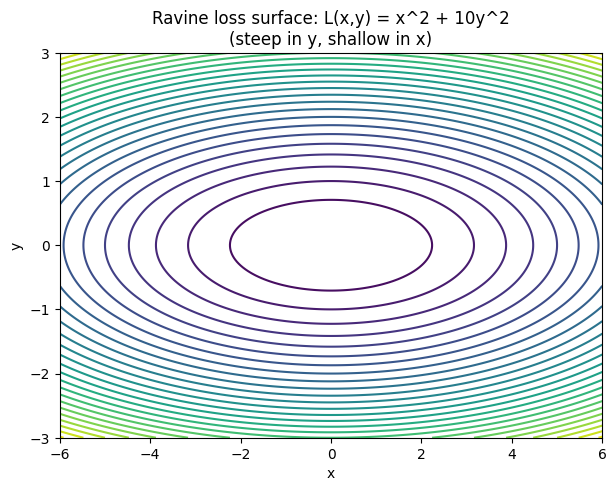

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# A classic "ravine" loss surface: steep in x, shallow in y
# L(x, y) = x^2 + 10*y^2   (imagine an elongated bowl)
def loss_fn(x, y):
    return x**2 + 10 * y**2

def grad_fn(x, y):
    return np.array([2*x, 20*y])

# Visualize the ravine
xx, yy = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-3, 3, 200))
zz = loss_fn(xx, yy)
plt.figure(figsize=(7, 5))
plt.contour(xx, yy, zz, levels=30, cmap='viridis')
plt.title("Ravine loss surface: L(x,y) = x^2 + 10y^2\n(steep in y, shallow in x)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [2]:
def plain_sgd(start, lr=0.1, steps=50):
    path = [start.copy()]
    w = start.copy()
    for _ in range(steps):
        g = grad_fn(*w)
        w = w - lr * g
        path.append(w.copy())
    return np.array(path)

def momentum_gd(start, lr=0.1, beta=0.9, steps=50):
    """Momentum: v is an EMA of past gradients, giving the update 'memory'."""
    path = [start.copy()]
    w = start.copy()
    v = np.zeros_like(w)
    for _ in range(steps):
        g = grad_fn(*w)
        v = beta * v + (1 - beta) * g        # <-- EMA of the gradient
        w = w - lr * v
        path.append(w.copy())
    return np.array(path)

def rmsprop_gd(start, lr=0.3, beta=0.9, eps=1e-8, steps=50):
    """RMSProp: EMA of squared gradients, adapting the step size per-parameter."""
    path = [start.copy()]
    w = start.copy()
    s = np.zeros_like(w)
    for _ in range(steps):
        g = grad_fn(*w)
        s = beta * s + (1 - beta) * g**2      # <-- EMA of squared gradient (not a running sum, unlike AdaGrad)
        w = w - lr * g / (np.sqrt(s) + eps)
        path.append(w.copy())
    return np.array(path)

def adam_gd(start, lr=0.5, beta1=0.9, beta2=0.999, eps=1e-8, steps=50):
    """Adam: combines Momentum's 'm' (direction) with RMSProp's 'v' (adaptive scale)."""
    path = [start.copy()]
    w = start.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    for t in range(1, steps + 1):
        g = grad_fn(*w)
        m = beta1 * m + (1 - beta1) * g            # 1st moment (like Momentum)
        v = beta2 * v + (1 - beta2) * g**2           # 2nd moment (like RMSProp)
        m_hat = m / (1 - beta1**t)                    # bias correction
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(w.copy())
    return np.array(path)

def adamw_gd(start, lr=0.5, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.05, steps=50):
    """AdamW: identical to Adam, but weight decay is a SEPARATE direct shrinkage step,
    decoupled from the adaptive m_hat/v_hat update."""
    path = [start.copy()]
    w = start.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    for t in range(1, steps + 1):
        g = grad_fn(*w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps) - lr * weight_decay * w  # <-- decoupled decay
        path.append(w.copy())
    return np.array(path)

start = np.array([5.0, 2.5])   # start far from the minimum at (0,0)
path_sgd = plain_sgd(start)
path_mom = momentum_gd(start)
path_rms = rmsprop_gd(start)
path_adam = adam_gd(start)
path_adamw = adamw_gd(start)

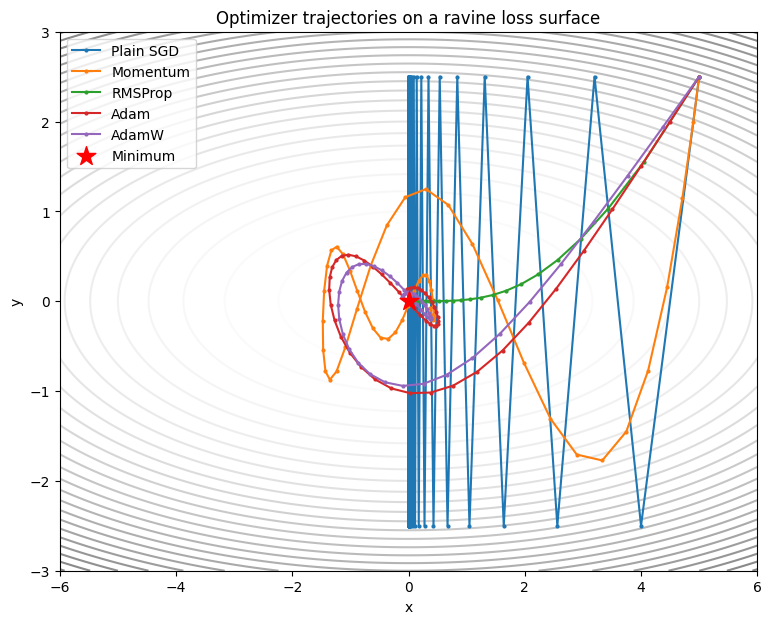

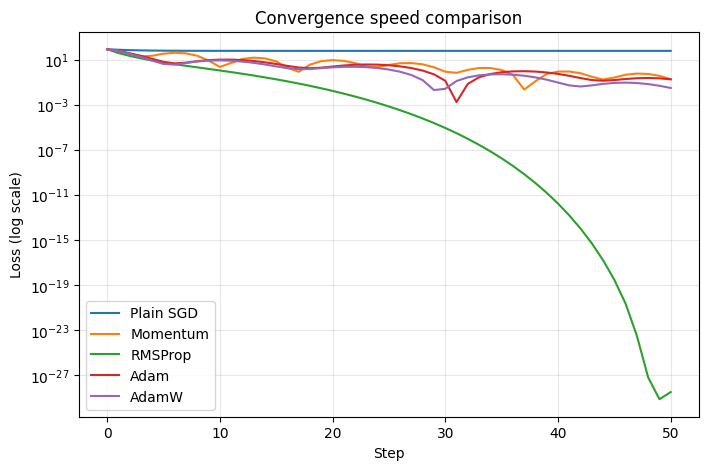

Notice: Plain SGD zig-zags across the steep 'y' direction (visible oscillation in the trajectory plot).
Momentum/RMSProp/Adam/AdamW all reach the minimum far more directly.


In [3]:
plt.figure(figsize=(9, 7))
plt.contour(xx, yy, zz, levels=30, cmap='Greys', alpha=0.5)
for path, label in [(path_sgd, 'Plain SGD'), (path_mom, 'Momentum'),
                     (path_rms, 'RMSProp'), (path_adam, 'Adam'), (path_adamw, 'AdamW')]:
    plt.plot(path[:, 0], path[:, 1], marker='o', markersize=2, label=label)
plt.scatter([0], [0], c='red', marker='*', s=200, zorder=5, label='Minimum')
plt.title("Optimizer trajectories on a ravine loss surface")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.show()

# Also compare convergence speed (loss vs. step)
plt.figure(figsize=(8, 5))
for path, label in [(path_sgd, 'Plain SGD'), (path_mom, 'Momentum'),
                     (path_rms, 'RMSProp'), (path_adam, 'Adam'), (path_adamw, 'AdamW')]:
    losses = [loss_fn(*p) for p in path]
    plt.plot(losses, label=label)
plt.yscale('log')
plt.xlabel("Step"); plt.ylabel("Loss (log scale)")
plt.title("Convergence speed comparison")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Notice: Plain SGD zig-zags across the steep 'y' direction (visible oscillation in the trajectory plot).")
print("Momentum/RMSProp/Adam/AdamW all reach the minimum far more directly.")

---
# Part B — PyTorch Equivalent

`torch.optim` ships production implementations of every optimizer above.

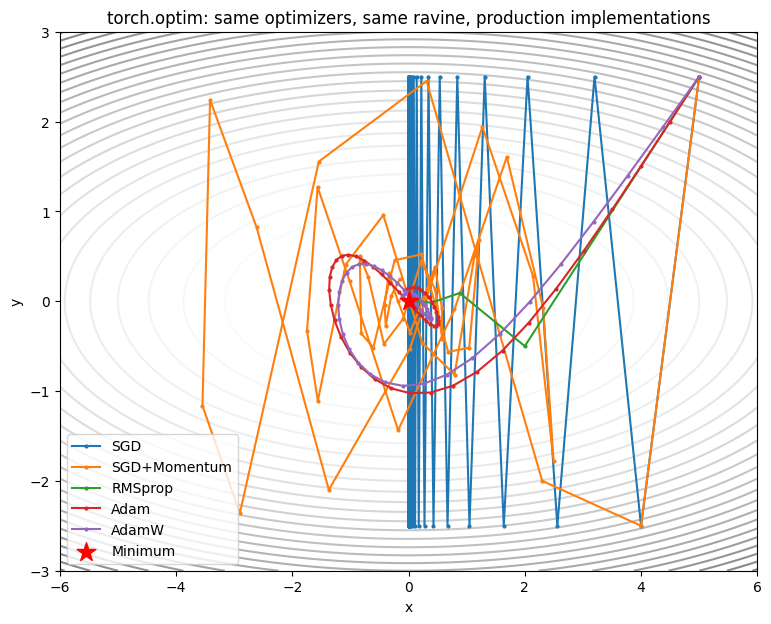

Compare this plot to Part A -- the trajectories should tell the same story:
plain SGD oscillates, every adaptive/momentum-based method cuts more directly to the minimum.


In [4]:
import torch

def run_torch_optimizer(optimizer_cls, start, steps=50, **opt_kwargs):
    w = torch.tensor(start, dtype=torch.float32, requires_grad=True)
    optimizer = optimizer_cls([w], **opt_kwargs)
    path = [w.detach().numpy().copy()]
    for _ in range(steps):
        optimizer.zero_grad()
        loss = w[0]**2 + 10 * w[1]**2       # same ravine loss, expressed with autograd
        loss.backward()                       # autograd computes the gradient automatically
        optimizer.step()
        path.append(w.detach().numpy().copy())
    return np.array(path)

start_np = np.array([5.0, 2.5])

path_sgd_t   = run_torch_optimizer(torch.optim.SGD, start_np, lr=0.1)
path_mom_t   = run_torch_optimizer(torch.optim.SGD, start_np, lr=0.1, momentum=0.9)
path_rms_t   = run_torch_optimizer(torch.optim.RMSprop, start_np, lr=0.3)
path_adam_t  = run_torch_optimizer(torch.optim.Adam, start_np, lr=0.5)
path_adamw_t = run_torch_optimizer(torch.optim.AdamW, start_np, lr=0.5, weight_decay=0.05)

plt.figure(figsize=(9, 7))
plt.contour(xx, yy, zz, levels=30, cmap='Greys', alpha=0.5)
for path, label in [(path_sgd_t, 'SGD'), (path_mom_t, 'SGD+Momentum'),
                     (path_rms_t, 'RMSprop'), (path_adam_t, 'Adam'), (path_adamw_t, 'AdamW')]:
    plt.plot(path[:, 0], path[:, 1], marker='o', markersize=2, label=label)
plt.scatter([0], [0], c='red', marker='*', s=200, zorder=5, label='Minimum')
plt.title("torch.optim: same optimizers, same ravine, production implementations")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.show()

print("Compare this plot to Part A -- the trajectories should tell the same story:")
print("plain SGD oscillates, every adaptive/momentum-based method cuts more directly to the minimum.")